# Frozen NTK Block Concentration on $S^1$

This notebook analyzes Monte Carlo concentration of
$$B_m^{(K)} - \Lambda_K,$$
where
$$B_m^{(K)} = P_K T_0 P_K \quad\text{and}\quad \Lambda_K = \operatorname{diag}(\lambda_0,\lambda_1,\lambda_1,\dots,\lambda_K,\lambda_K).$$

## Setup

- Circle grid: evenly spaced points on $[0,2\pi)$
- Fourier block dimension: $d = 2K+1$
- Empirical operator: $A_0 = K_0/n$
- Block used in this experiment:
  $$B_m^{(K)} = \frac{1}{n}\Phi^\top A_0\Phi$$
- Main concentration norm: $\|B_m^{(K)}-\Lambda_K\|_{\max}$

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / 'utils').exists() and (ROOT.parent / 'utils').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.artifacts_io import latest_run_dir, load_manifest

PLOT_DIR = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_block_concentration_on_s1'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

In [2]:
EXP_NAME = 'ntk_frozen_block_concentration_on_S1'
RUN_DIR = latest_run_dir(ROOT / 'results', EXP_NAME)
if RUN_DIR is None:
    raise FileNotFoundError(f'No run found for {EXP_NAME}. Run the experiment first.')

manifest = load_manifest(RUN_DIR)
summary = np.load(RUN_DIR / manifest['summary'])
theory = np.load(RUN_DIR / manifest['theory_reference'])

widths = np.asarray(summary['widths'], dtype=int)
run_npz = {int(w): np.load(RUN_DIR / manifest['runs'][str(int(w))]) for w in widths}

err_max_by_width = [np.asarray(run_npz[int(w)]['err_max'], dtype=float) for w in widths]
err_fro_by_width = [np.asarray(run_npz[int(w)]['err_fro'], dtype=float) for w in widths]
err_op_by_width = [np.asarray(run_npz[int(w)]['err_op'], dtype=float) for w in widths]

print('Run dir:', RUN_DIR)
print('n_points:', manifest['meta']['n_points'])
print('K_max:', manifest['meta']['K_max'])
print('d:', manifest['meta']['d'])
print('widths:', widths.tolist())
print('seeds per width:', [len(v) for v in err_max_by_width])

Run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/ntk_frozen_block_concentration_on_S1/20260423-230417-4628f571
n_points: 4096
K_max: 10
d: 21
widths: [32, 64, 128, 256, 512, 1024]
seeds per width: [100, 100, 100, 100, 100, 100]


## 1) Seed Scatter vs Width

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_block_concentration_on_s1/01_seed_scatter_vs_width.png


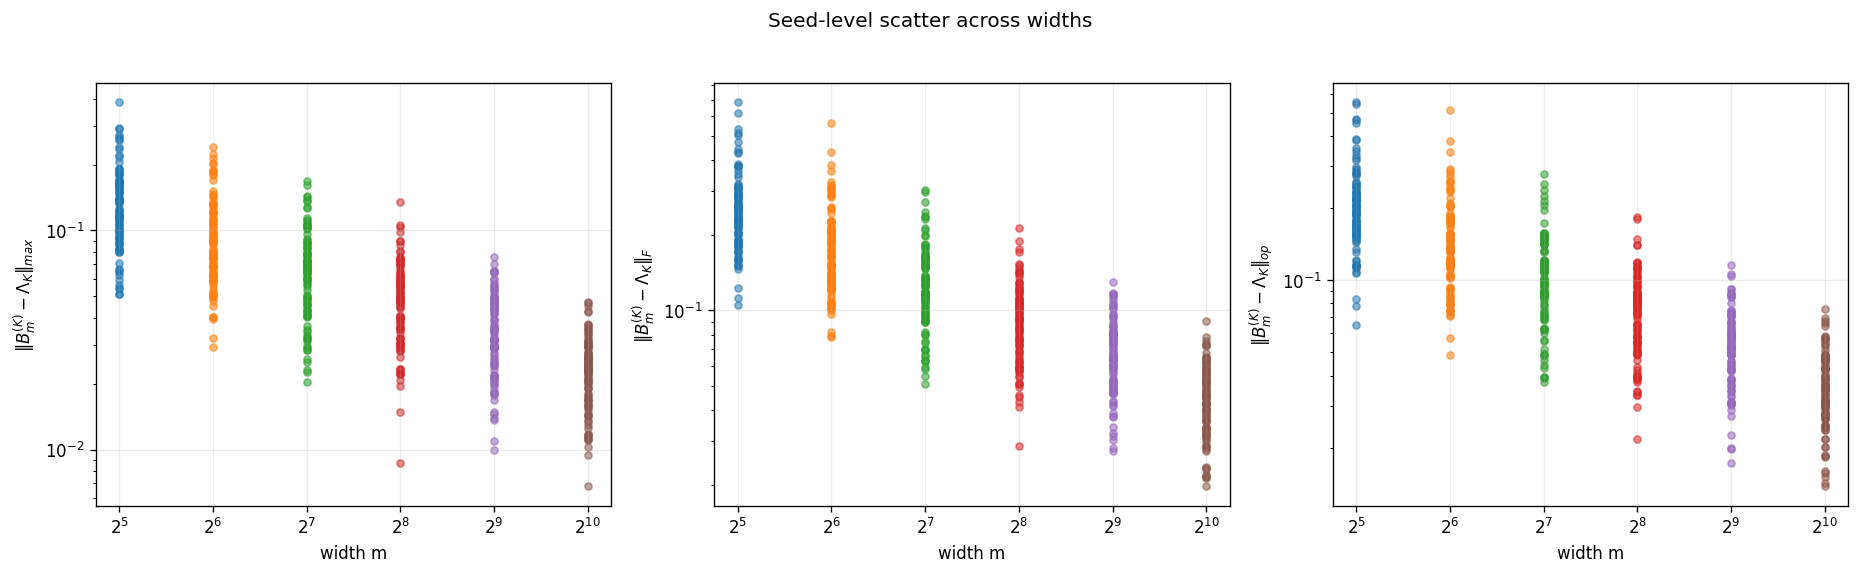

In [3]:
norm_panels = [
    (err_max_by_width, r'$\|B_m^{(K)}-\Lambda_K\|_{max}$'),
    (err_fro_by_width, r'$\|B_m^{(K)}-\Lambda_K\|_F$'),
    (err_op_by_width, r'$\|B_m^{(K)}-\Lambda_K\|_{op}$'),
]

fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.6), sharex=True)
for ax, (arrs, ylab) in zip(axes, norm_panels):
    for i, w in enumerate(widths):
        vals = np.asarray(arrs[i], dtype=float)
        ax.scatter(np.full(vals.shape, w, dtype=float), vals, s=18, alpha=0.55)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width m')
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.25)

fig.suptitle('Seed-level scatter across widths', y=1.03)
fig.tight_layout()
filename = PLOT_DIR / '01_seed_scatter_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## 2) Empirical Median + $(1-\delta)$-Quantile

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_block_concentration_on_s1/02_median_and_quantile_vs_width.png


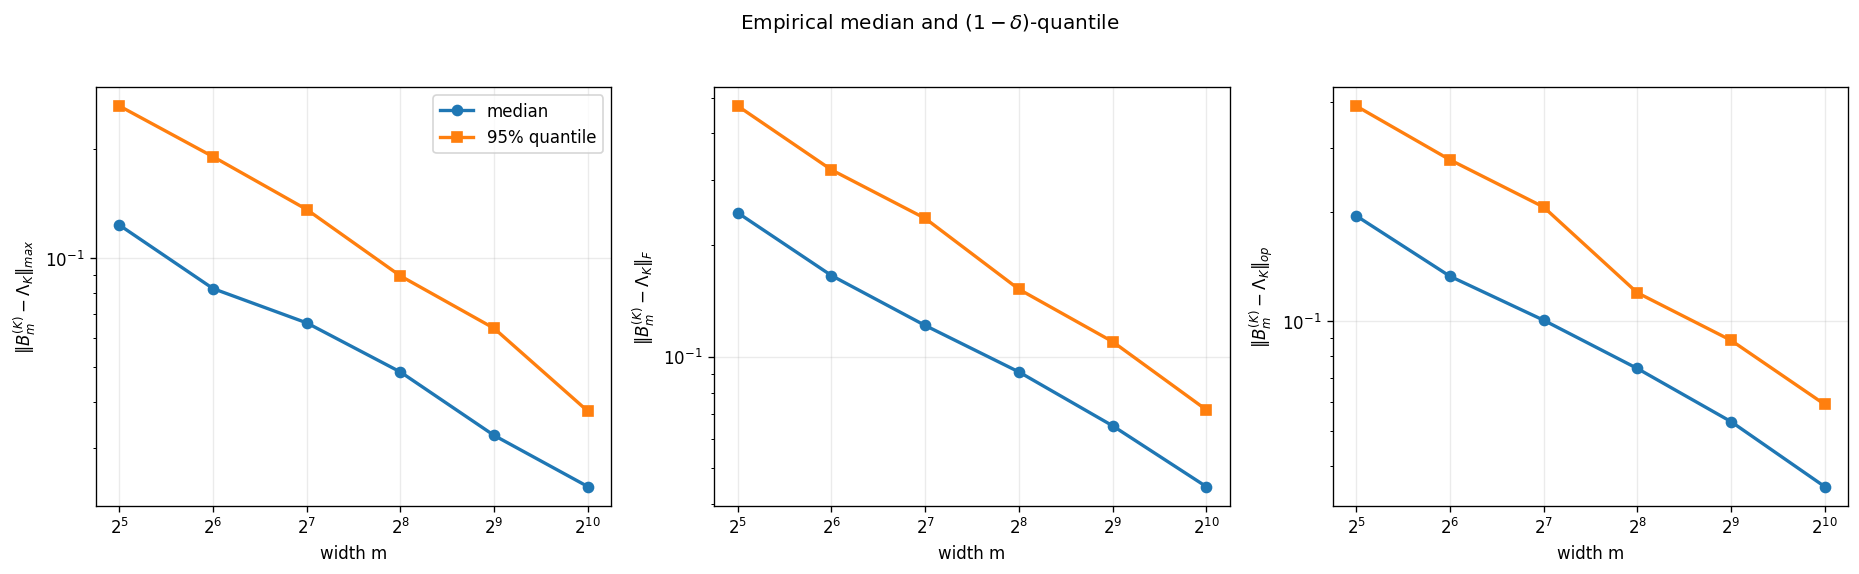

In [4]:
delta = 0.05
q_level = 1.0 - delta

def stats_by_width(arrs):
    med = np.array([np.median(np.asarray(v, dtype=float)) for v in arrs], dtype=float)
    qhi = np.array([np.quantile(np.asarray(v, dtype=float), q_level) for v in arrs], dtype=float)
    return med, qhi

fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.6), sharex=True)
for ax, (arrs, ylab) in zip(axes, norm_panels):
    med, qhi = stats_by_width(arrs)
    ax.plot(widths, med, marker='o', linewidth=2.0, label='median')
    ax.plot(widths, qhi, marker='s', linewidth=2.0, label=fr'{q_level:.0%} quantile')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width m')
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.25)

axes[0].legend()
fig.suptitle(r'Empirical median and $(1-\delta)$-quantile', y=1.03)
fig.tight_layout()
filename = PLOT_DIR / '02_median_and_quantile_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## 3) Theoretical Envelope (Non-Rescaled)

Using c = 0.20000000298023224
Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_block_concentration_on_s1/03_theoretical_envelope_non_rescaled.png


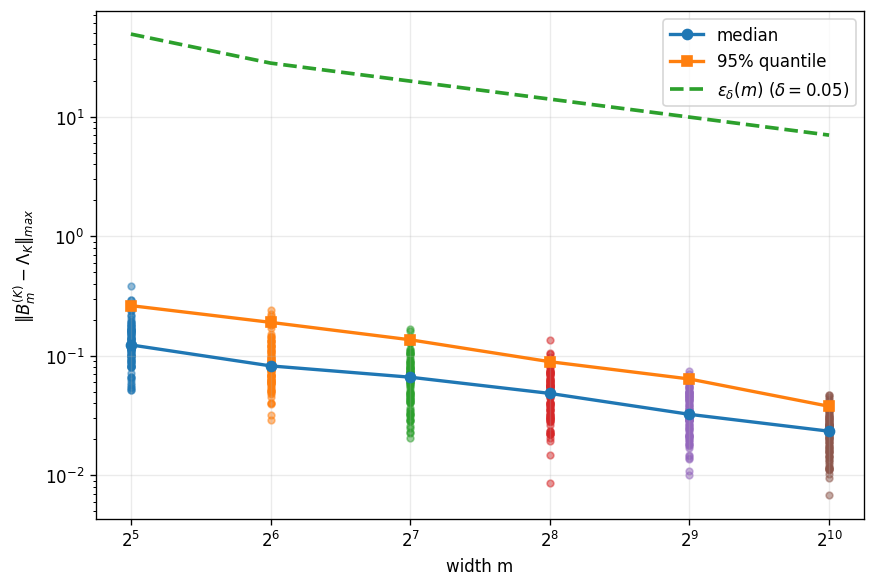

In [5]:
# For max-norm concentration bound
d = int(manifest['meta']['d'])
L = float(manifest['meta']['subexp_L'])
c_grid = np.asarray(summary['c_grid'], dtype=float)
C_TO_PLOT = 0.2
c_idx = int(np.argmin(np.abs(c_grid - C_TO_PLOT)))
c_value = float(c_grid[c_idx])
print('Using c =', c_value)

def epsilon_delta(widths, delta, d, L, c):
    widths = np.asarray(widths, dtype=float)
    t = np.log(2.0 * (d**2) / delta) / (c * widths)
    eps = np.where(t <= 1.0, L * np.sqrt(t), L * t)
    return eps

eps_delta_curve = epsilon_delta(widths, delta, d, L, c_value)
med_max, qhi_max = stats_by_width(err_max_by_width)

plt.figure(figsize=(7.4, 5.0))
for i, w in enumerate(widths):
    vals = np.asarray(err_max_by_width[i], dtype=float)
    plt.scatter(np.full(vals.shape, w, dtype=float), vals, s=16, alpha=0.5)
plt.plot(widths, med_max, marker='o', linewidth=2.0, label='median')
plt.plot(widths, qhi_max, marker='s', linewidth=2.0, label=fr'{q_level:.0%} quantile')
plt.plot(widths, eps_delta_curve, '--', linewidth=2.2, label=fr'$\epsilon_\delta(m)$ ($\delta={delta}$)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('width m')
plt.ylabel(r'$\|B_m^{(K)}-\Lambda_K\|_{max}$')
# plt.title('Empirical concentration vs theoretical envelope')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
filename = PLOT_DIR / '03_theoretical_envelope_non_rescaled.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## 4) Exceedance Check at $\epsilon_\delta(m)$

In [6]:
print(f'Exceedance check at epsilon_delta(m), delta={delta}, c={c_value}')
print(' width   epsilon_delta      exceed / total      empirical_prob')
for i, w in enumerate(widths):
    vals = np.asarray(err_max_by_width[i], dtype=float)
    eps = float(eps_delta_curve[i])
    exc = int(np.sum(vals >= eps))
    tot = int(vals.size)
    print(f'{int(w):6d}   {eps: .4e}      {exc:3d} / {tot:3d}         {exc/tot: .4f}')

Exceedance check at epsilon_delta(m), delta=0.05, c=0.20000000298023224
 width   epsilon_delta      exceed / total      empirical_prob
    32    4.8890e+01        0 / 100          0.0000
    64    2.7968e+01        0 / 100          0.0000
   128    1.9777e+01        0 / 100          0.0000
   256    1.3984e+01        0 / 100          0.0000
   512    9.8883e+00        0 / 100          0.0000
  1024    6.9921e+00        0 / 100          0.0000


## 5) Fixed-$\epsilon$ Exceedance vs Width

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_block_concentration_on_s1/05_fixed_epsilon_exceedance_vs_width.png


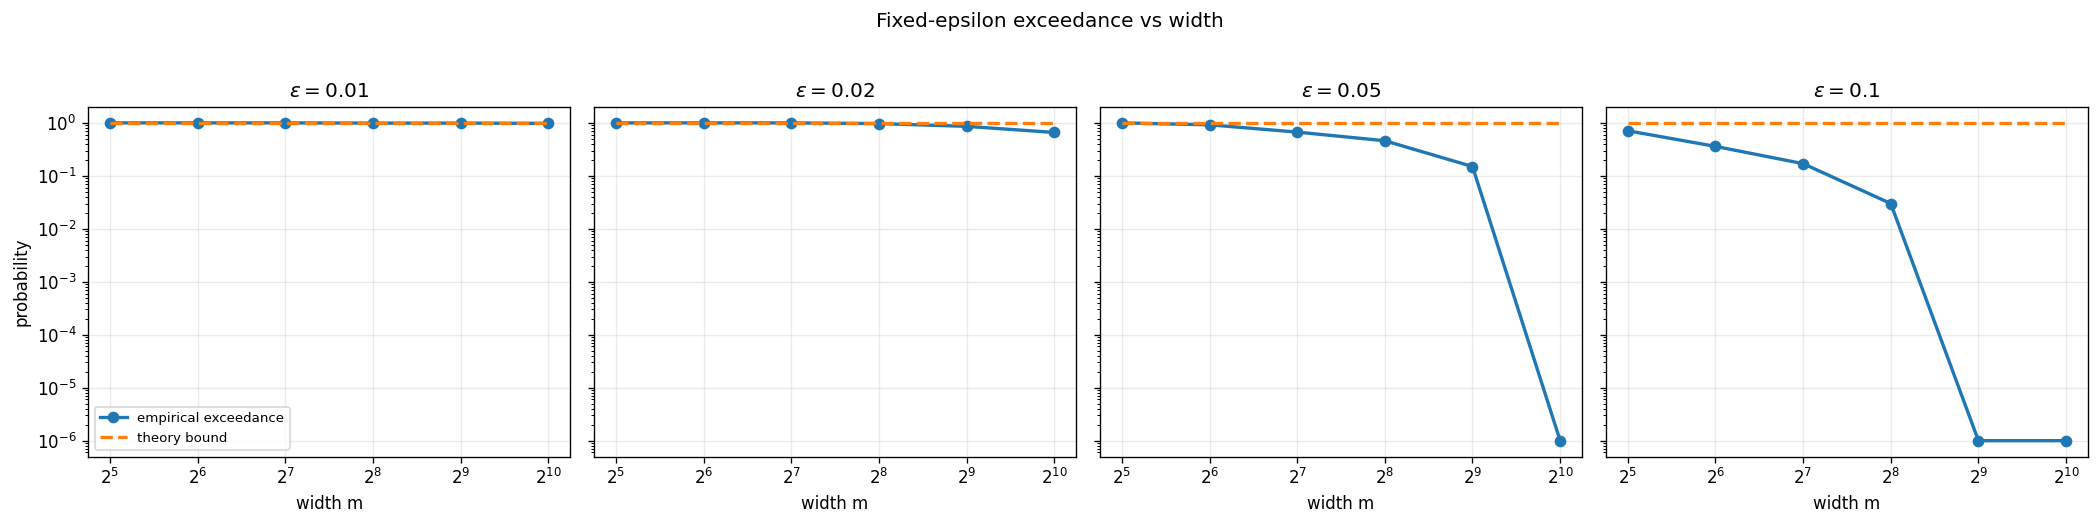

In [7]:
eps_grid = np.asarray(summary['eps_grid'], dtype=float)
theory_bound = np.asarray(summary['theory_bound_max_by_width'], dtype=float)[:, c_idx, :]

emp_exceed = np.zeros((len(widths), len(eps_grid)), dtype=float)
for i, w in enumerate(widths):
    vals = np.asarray(err_max_by_width[i], dtype=float)
    for j, eps in enumerate(eps_grid):
        emp_exceed[i, j] = np.mean(vals >= eps)

fig, axes = plt.subplots(1, len(eps_grid), figsize=(4.4 * len(eps_grid), 4.2), sharey=True)
if len(eps_grid) == 1:
    axes = [axes]

for j, eps in enumerate(eps_grid):
    ax = axes[j]
    y_emp = np.maximum(emp_exceed[:, j], 1e-6)
    y_th = np.maximum(theory_bound[:, j], 1e-6)
    ax.plot(widths, y_emp, marker='o', linewidth=2.0, label='empirical exceedance')
    ax.plot(widths, y_th, '--', linewidth=2.0, label='theory bound')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width m')
    ax.set_title(rf'$\epsilon={eps:.3g}$')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('probability')
axes[0].legend(fontsize=8)
fig.suptitle('Fixed-epsilon exceedance vs width', y=1.03)
fig.tight_layout()
filename = PLOT_DIR / '05_fixed_epsilon_exceedance_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()